# Validación de Curvas — Diseño Factorial 3² con Ventilador Hamilton S1

Compara las curvas dinámicas de Presión, Flujo y Volumen del simulador numérico contra
las mediciones del ventilador mecánico Hamilton S1, usando datos capturados en el
laboratorio Vesalius (Universidad EIA) con el simulador pulmonar mecánico Ingmar Medical
(modelo 20.00.000, dos compartimentos).

**Diseño experimental:** factorial 3² (Compliance × Resistencia), 3 réplicas, 27 corridas.
**Modo:** VCV flujo cuadrado, Vt=500 mL, PEEP=5 cmH₂O, FR=15 rpm, I:E=1:2.
**Métricas:** RMSE por variable, CCC (Lin), Bland-Altman sobre PIP.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d


plt.style.use("seaborn-v0_8-whitegrid")


def preparar_pares(y_fisico, y_simulado):
    """
    Convierte ambas series a arrays float y elimina pares que contengan
    valores NaN o infinitos.
    """
    y_fisico = np.asarray(y_fisico, dtype=float)
    y_simulado = np.asarray(y_simulado, dtype=float)

    if y_fisico.shape != y_simulado.shape:
        raise ValueError(
            "Las series física y simulada deben tener la misma forma. "
            f"Recibidas: {y_fisico.shape} y {y_simulado.shape}."
        )

    validos = np.isfinite(y_fisico) & np.isfinite(y_simulado)

    if validos.sum() < 2:
        raise ValueError("No hay suficientes pares válidos para calcular la métrica.")

    return y_fisico[validos], y_simulado[validos]


def rmse(y_fisico, y_simulado):
    """Raíz del error cuadrático medio."""
    y_fisico, y_simulado = preparar_pares(y_fisico, y_simulado)
    return float(np.sqrt(np.mean((y_fisico - y_simulado) ** 2)))


def calcular_ccc(y_fisico, y_simulado):
    """
    Coeficiente de correlación de concordancia de Lin.

    Se calcula directamente a partir de la covarianza y las varianzas
    muestrales.
    """
    y_fisico, y_simulado = preparar_pares(y_fisico, y_simulado)

    media_fis = np.mean(y_fisico)
    media_sim = np.mean(y_simulado)

    var_fis = np.var(y_fisico, ddof=1)
    var_sim = np.var(y_simulado, ddof=1)
    covarianza = np.cov(y_fisico, y_simulado, ddof=1)[0, 1]

    denominador = (
        var_fis
        + var_sim
        + (media_fis - media_sim) ** 2
    )

    if np.isclose(denominador, 0.0):
        return np.nan

    return float(2.0 * covarianza / denominador)

In [2]:
class Paciente:
    def __init__(self, R1=5, C1=0.05, R2=10, C2=0.05):
        self.R1 = R1
        self.C1 = C1
        self.R2 = R2
        self.C2 = C2
        self.E1 = 1 / self.C1
        self.E2 = 1 / self.C2


class Ventilador:
    def __init__(self, modo='PCV', PEEP=5.0, P_driving=15.0, fr=20.0, Ti=1.0, Vt=None):
        self.modo = modo
        self.PEEP = PEEP
        self.P_driving = P_driving
        self.fr = fr
        self.Ti = Ti
        self.T_total = 60.0 / fr
        self.Vt = Vt
        if modo == 'VCV':
            assert Vt is not None, "Se requiere Vt para modo VCV"
            self.flow_insp = Vt / Ti
        else:
            self.flow_insp = None

    def presion(self, t):
        t_arr = np.asarray(t)
        en_insp = (t_arr % self.T_total) < self.Ti
        if self.modo == 'PCV':
            return np.where(en_insp, self.PEEP + self.P_driving, self.PEEP)
        elif self.modo == 'VCV':
            return np.full_like(t_arr, self.PEEP)
        else:
            raise ValueError(f"Modo desconocido: {self.modo}")

    def flujo(self, t):
        if self.modo != 'VCV':
            return np.zeros_like(np.asarray(t))
        t_arr = np.asarray(t)
        return np.where((t_arr % self.T_total) < self.Ti, self.flow_insp, 0.0)


class Simulador:
    def __init__(self, paciente, ventilador, control=None):
        self.paciente = paciente
        self.ventilador = ventilador
        self.control = control

    def _edo_insp(self, t, y):
        V1, V2 = y
        pac, vent = self.paciente, self.ventilador
        if vent.modo == 'VCV':
            flow = vent.flow_insp
            P_aw = (flow + pac.E1*V1/pac.R1 + pac.E2*V2/pac.R2) / (1/pac.R1 + 1/pac.R2)
        else:
            P_aw = vent.PEEP + vent.P_driving
        return [(P_aw - pac.E1*V1)/pac.R1, (P_aw - pac.E2*V2)/pac.R2]

    def _edo_esp(self, t, y):
        V1, V2 = y
        pac, vent = self.paciente, self.ventilador
        R_exp = 5.0
        A = vent.PEEP - pac.E1*V1
        B = vent.PEEP - pac.E2*V2
        D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
        return [(A*(pac.R2+R_exp) - B*R_exp)/D, (B*(pac.R1+R_exp) - A*R_exp)/D]

    def simular(self, num_ciclos=15, pasos_por_ciclo=100):
        t_data, V1_data, V2_data = [], [], []
        V0 = [0.0, 0.0]
        for i in range(num_ciclos):
            t0   = i * self.ventilador.T_total
            t_Ti = t0 + self.ventilador.Ti
            t1   = t0 + self.ventilador.T_total
            n_insp = max(10, int(pasos_por_ciclo * self.ventilador.Ti / self.ventilador.T_total))
            n_esp  = max(10, pasos_por_ciclo - n_insp)
            t_eval_i = np.linspace(t0, t_Ti, n_insp, endpoint=False)
            sol_i = solve_ivp(self._edo_insp, [t0, t_Ti], V0,
                              t_eval=t_eval_i, method='RK45', max_step=0.05)
            V_mid = sol_i.y[:, -1]
            t_eval_e = np.linspace(t_Ti, t1, n_esp, endpoint=(i == num_ciclos-1))
            sol_e = solve_ivp(self._edo_esp, [t_Ti, t1], V_mid,
                              t_eval=t_eval_e, method='RK45', max_step=0.05)
            t_data.extend([sol_i.t, sol_e.t])
            V1_data.extend([sol_i.y[0], sol_e.y[0]])
            V2_data.extend([sol_i.y[1], sol_e.y[1]])
            V0 = sol_e.y[:, -1]
        return np.concatenate(t_data), np.concatenate(V1_data), np.concatenate(V2_data)

    def procesar_resultados(self, t, V1, V2):
        Vt = V1 + V2
        R_exp = 5.0
        pac, vent = self.paciente, self.ventilador
        en_insp = (t % vent.T_total) < vent.Ti

        flow_ctrl = vent.flow_insp * np.ones_like(t)
        P_aw_i = (flow_ctrl + pac.E1*V1/pac.R1 + pac.E2*V2/pac.R2) / (1/pac.R1 + 1/pac.R2)
        f1_i = (P_aw_i - pac.E1*V1) / pac.R1
        f2_i = (P_aw_i - pac.E2*V2) / pac.R2

        A = vent.PEEP - pac.E1*V1
        B = vent.PEEP - pac.E2*V2
        D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
        f1_e = (A*(pac.R2+R_exp) - B*R_exp) / D
        f2_e = (B*(pac.R1+R_exp) - A*R_exp) / D

        flujo1 = np.where(en_insp, f1_i, f1_e)
        flujo2 = np.where(en_insp, f2_i, f2_e)
        flujo_total = flujo1 + flujo2

        P_aw_esp = vent.PEEP - flujo_total * R_exp
        P_aw = np.where(en_insp, P_aw_i, P_aw_esp)

        return {'t': t, 'V1': V1, 'V2': V2, 'Vt': Vt,
                'flow1': flujo1, 'flow2': flujo2, 'flow': flujo_total, 'P_aw': P_aw}

In [3]:
# Rutas
BASE      = "../../"
DATOS_DIR = BASE + "JulianQ/"

# Parámetros del experimento (fijados en todas las corridas)
FR      = 15.0
T_TOTAL = 60.0 / FR       # 4.0 s
TI      = T_TOTAL / 3.0   # 1.333 s  (I:E = 1:2)
VT      = 0.5             # L
PEEP    = 5.0             # cmH₂O

NUM_CICLOS_SIM  = 10
PASOS_POR_CICLO = 400

# Cargar la matriz del experimento (encoding latin-1 / Windows-1252)
df_exp = pd.read_csv(BASE + "matriz_experimento_ventilador.csv", sep=';', index_col=0,
                     encoding='latin-1')
df_exp.columns = df_exp.columns.str.strip()
df_exp = df_exp.rename(columns={
    'Medici\xf3n Compliance': 'C_medido',
    'Medici\xf3n Resistencia': 'R_medido',
})
# Fallback: si los nombres ya llegaron limpios, renombrar por posición
if 'C_medido' not in df_exp.columns:
    cols = list(df_exp.columns)
    df_exp = df_exp.rename(columns={cols[2]: 'C_medido', cols[3]: 'R_medido'})

# Construir nombre de archivo desde la columna Hora  (formato HH:MM → HH-MM)
def hora_a_filename(hora):
    h, m = hora.strip().split(':')
    return f"hm_Waveform 26-05-08-{h}-{m}.txt"

df_exp['archivo'] = df_exp['Hora'].apply(hora_a_filename)
# Corrección puntual: la corrida con hora '15:47' corresponde al archivo '15-46'
df_exp.loc[df_exp['Hora'].str.strip() == '15:47', 'archivo'] = 'hm_Waveform 26-05-08-15-46.txt'

print(df_exp[['Compliance', 'Resistencia', 'C_medido', 'R_medido', 'Hora', 'archivo']].to_string())

   Compliance Resistencia  C_medido  R_medido   Hora                         archivo
z                                                                                   
1        Alta        Alta        62        20  15:13  hm_Waveform 26-05-08-15-13.txt
2       Media       Media        49        15  15:16  hm_Waveform 26-05-08-15-16.txt
3        Baja        Baja        42         2  15:26  hm_Waveform 26-05-08-15-26.txt
4       Media        Baja        51         4  15:29  hm_Waveform 26-05-08-15-29.txt
5        Baja        Baja        43         3  15:32  hm_Waveform 26-05-08-15-32.txt
6        Baja        Alta        35        17  15:35  hm_Waveform 26-05-08-15-35.txt
7        Alta       Media        60        11  15:40  hm_Waveform 26-05-08-15-40.txt
8        Alta        Alta        58        20  15:43  hm_Waveform 26-05-08-15-43.txt
9       Media        Baja        47         5  15:47  hm_Waveform 26-05-08-15-46.txt
10       Alta        Baja        64         5  15:49  hm_Waveform

In [4]:
def cargar_ciclo_ventilador(
    filepath,
    incluir_muestra_previa=False,
):
    """
    Carga una única respiración completa del datalogger.

    Si incluir_muestra_previa=True, añade una muestra perteneciente
    a la respiración anterior. Esta muestra se utiliza solamente para
    interpolar el inicio inspiratorio y no forma parte de la curva
    analizada después de la sincronización.
    """
    df = pd.read_csv(
        filepath,
        sep="\t",
        skiprows=2,
        encoding="latin-1",
    )
    df.columns = df.columns.str.strip()

    columnas_requeridas = {
        "Time(ms)",
        "Breath",
        "Paw (cmH2O)",
        "Flow (l/min)",
        "Volume (ml)",
    }

    faltantes = columnas_requeridas.difference(df.columns)

    if faltantes:
        raise ValueError(
            f"Faltan columnas en {filepath}: {sorted(faltantes)}"
        )

    columnas_numericas = [
        "Time(ms)",
        "Breath",
        "Paw (cmH2O)",
        "Flow (l/min)",
        "Volume (ml)",
    ]

    for columna in columnas_numericas:
        df[columna] = pd.to_numeric(
            df[columna],
            errors="coerce",
        )

    df = (
        df.dropna(subset=columnas_numericas)
        .sort_values("Time(ms)")
        .reset_index(drop=True)
    )

    respiraciones = df["Breath"].drop_duplicates().tolist()

    if len(respiraciones) < 3:
        raise ValueError(
            f"El archivo {filepath} no contiene suficientes "
            "respiraciones completas."
        )

    UMBRAL_FLUJO = 5.0  # L/min

    # Se descartan la primera y la última respiración.
    candidatas = respiraciones[1:-1]

    for numero_respiracion in reversed(candidatas):
        mascara = df["Breath"] == numero_respiracion
        indices_ciclo = df.index[mascara].to_numpy()

        ciclo = df.loc[indices_ciclo].copy()

        tiene_inspiracion = (
            ciclo["Flow (l/min)"] > UMBRAL_FLUJO
        ).any()

        tiene_espiracion = (
            ciclo["Flow (l/min)"] < -UMBRAL_FLUJO
        ).any()

        if not (tiene_inspiracion and tiene_espiracion):
            continue

        # La referencia temporal continúa siendo la primera muestra
        # etiquetada como perteneciente a la respiración elegida.
        tiempo_referencia_ms = float(
            ciclo["Time(ms)"].iloc[0]
        )

        datos_salida = ciclo

        if incluir_muestra_previa:
            indice_inicial = int(indices_ciclo[0])

            if indice_inicial > 0:
                muestra_previa = df.loc[[indice_inicial - 1]]
                datos_salida = pd.concat(
                    [muestra_previa, ciclo],
                    axis=0,
                )

        tiempo_ms = datos_salida[
            "Time(ms)"
        ].to_numpy(dtype=float)

        # Si se añadió una muestra previa, el primer tiempo será
        # aproximadamente -0.032 s.
        t = (
            tiempo_ms - tiempo_referencia_ms
        ) / 1000.0

        P = datos_salida[
            "Paw (cmH2O)"
        ].to_numpy(dtype=float)

        F = (
            datos_salida[
                "Flow (l/min)"
            ].to_numpy(dtype=float)
            / 60.0
        )

        V = (
            datos_salida[
                "Volume (ml)"
            ].to_numpy(dtype=float)
            / 1000.0
        )

        return t, P, F, V

    raise ValueError(
        f"No se encontró una respiración completa en {filepath}."
    )

In [5]:
ruta_prueba = DATOS_DIR + df_exp.iloc[0]["archivo"]

t_prueba, P_prueba, F_prueba, V_prueba = cargar_ciclo_ventilador(
    ruta_prueba
)

print(f"Archivo: {ruta_prueba}")
print(f"Número de muestras: {len(t_prueba)}")
print(f"Duración observada: {t_prueba[-1]:.3f} s")
print(f"Flujo máximo: {F_prueba.max() * 60:.2f} L/min")
print(f"Flujo mínimo: {F_prueba.min() * 60:.2f} L/min")

Archivo: ../../JulianQ/hm_Waveform 26-05-08-15-13.txt
Número de muestras: 133
Duración observada: 4.224 s
Flujo máximo: 22.65 L/min
Flujo mínimo: -19.35 L/min


In [6]:
def interpolar_cruce_cero(t1, y1, t2, y2):
    """
    Estima mediante interpolación lineal el instante en que una señal
    cruza por cero entre dos muestras consecutivas.
    """
    if np.isclose(y1, y2):
        return float((t1 + t2) / 2.0)

    return float(t1 - y1 * (t2 - t1) / (y2 - y1))


def caracterizar_ciclo_fisico(t, P, F, V):
    """
    Caracteriza temporalmente una respiración física completa.

    Parámetros de entrada:
        t : tiempo en segundos
        P : presión en cmH2O
        F : flujo en L/s
        V : volumen en L

    El final de la inspiración se define mediante el primer cruce del
    flujo de positivo a negativo posterior al flujo inspiratorio máximo.
    """
    t = np.asarray(t, dtype=float)
    P = np.asarray(P, dtype=float)
    F = np.asarray(F, dtype=float)
    V = np.asarray(V, dtype=float)

    if not (len(t) == len(P) == len(F) == len(V)):
        raise ValueError("Las señales del ciclo deben tener la misma longitud.")

    if len(t) < 3:
        raise ValueError("El ciclo no contiene suficientes muestras.")

    diferencias_t = np.diff(t)

    if np.any(diferencias_t <= 0):
        raise ValueError("El tiempo debe ser estrictamente creciente.")

    dt_muestreo = float(np.median(diferencias_t))

    # La última muestra representa el inicio del último intervalo.
    periodo_estimado = float(t[-1] - t[0] + dt_muestreo)
    fr_estimada = 60.0 / periodo_estimado

    # Se busca el final inspiratorio después del máximo flujo positivo.
    indice_flujo_maximo = int(np.argmax(F))

    cruces = np.where(
        (F[:-1] > 0.0)
        & (F[1:] <= 0.0)
        & (np.arange(len(F) - 1) >= indice_flujo_maximo)
    )[0]

    if len(cruces) == 0:
        raise ValueError(
            "No se encontró una transición de inspiración a espiración."
        )

    i = int(cruces[0])

    tiempo_fin_inspiracion = interpolar_cruce_cero(
        t[i],
        F[i],
        t[i + 1],
        F[i + 1],
    )

    # Interpolación del volumen en el cruce de flujo por cero.
    fraccion = (
        (tiempo_fin_inspiracion - t[i])
        / (t[i + 1] - t[i])
    )

    volumen_fin_inspiracion = (
        V[i]
        + fraccion * (V[i + 1] - V[i])
        - V[0]
    )

    # Flujo representativo del tramo estable, excluyendo las transiciones.
    mascara_flujo_estable = (
        (t >= 0.20 * tiempo_fin_inspiracion)
        & (t <= 0.80 * tiempo_fin_inspiracion)
        & (F > 0.0)
    )

    if mascara_flujo_estable.sum() < 3:
        flujo_estable = np.nan
    else:
        flujo_estable = float(np.median(F[mascara_flujo_estable]))

    return {
        "dt_muestreo_s": dt_muestreo,
        "periodo_s": periodo_estimado,
        "FR_estimada_rpm": fr_estimada,
        "Ti_efectivo_s": tiempo_fin_inspiracion,
        "flujo_estable_Lmin": flujo_estable * 60.0,
        "VT_fin_inspiracion_mL": volumen_fin_inspiracion * 1000.0,
        "PIP_fis_cmH2O": float(np.max(P)),
    }

In [7]:
diagnostico_temporal = []

for idx, fila in df_exp.iterrows():
    ruta = DATOS_DIR + fila["archivo"]

    t_fis, P_fis, F_fis, V_fis = cargar_ciclo_ventilador(
        ruta,
        incluir_muestra_previa=False,
    )

    diagnostico = caracterizar_ciclo_fisico(
        t_fis,
        P_fis,
        F_fis,
        V_fis,
    )

    diagnostico_temporal.append({
        "Orden": idx,
        "Compliance": fila["Compliance"],
        "Resistencia": fila["Resistencia"],
        **diagnostico,
    })

df_temporal = pd.DataFrame(diagnostico_temporal)

columnas_resumen = [
    "dt_muestreo_s",
    "periodo_s",
    "FR_estimada_rpm",
    "Ti_efectivo_s",
    "flujo_estable_Lmin",
    "VT_fin_inspiracion_mL",
]

print(
    df_temporal[columnas_resumen]
    .describe()
    .loc[["mean", "std", "min", "50%", "max"]]
    .round(3)
)

print("\nCorridas con los tiempos inspiratorios más extremos:")
print(
    df_temporal[
        [
            "Orden",
            "Compliance",
            "Resistencia",
            "periodo_s",
            "FR_estimada_rpm",
            "Ti_efectivo_s",
        ]
    ]
    .sort_values("Ti_efectivo_s")
    .iloc[np.r_[0:3, -3:0]]
    .round(3)
    .to_string(index=False)
)

      dt_muestreo_s  periodo_s  FR_estimada_rpm  Ti_efectivo_s  \
mean          0.032      4.288           13.995          1.351   
std           0.000      0.054            0.176          0.050   
min           0.032      4.192           13.686          1.187   
50%           0.032      4.288           13.993          1.362   
max           0.032      4.384           14.313          1.403   

      flujo_estable_Lmin  VT_fin_inspiracion_mL  
mean              22.008                475.779  
std                0.122                  6.500  
min               21.750                460.975  
50%               22.050                477.500  
max               22.200                483.702  

Corridas con los tiempos inspiratorios más extremos:
 Orden Compliance Resistencia  periodo_s  FR_estimada_rpm  Ti_efectivo_s
    26       Baja       Media      4.224           14.205          1.187
    24       Baja       Media      4.192           14.313          1.257
    13      Media        Alta 

In [8]:
# Parámetros nominales consignados en el protocolo/informe
parametros_nominales = {
    "FR_rpm": 15.0,
    "periodo_s": 60.0 / 15.0,
    "Ti_s": (60.0 / 15.0) / 3.0,
    "VT_L": 0.500,
    "PEEP_cmH2O": 5.0,
}

# Parámetros temporales observados en los 27 registros.
# Se usa la mediana global para evitar ajustar el simulador
# individualmente a cada curva física.
periodo_observado = float(df_temporal["periodo_s"].median())
ti_observado = float(df_temporal["Ti_efectivo_s"].median())
flujo_observado = float(df_temporal["flujo_estable_Lmin"].median())

parametros_observados = {
    "FR_rpm": 60.0 / periodo_observado,
    "periodo_s": periodo_observado,
    "Ti_s": ti_observado,
    "VT_L": 0.500,
    "PEEP_cmH2O": 5.0,
}

def calcular_relacion_ie(periodo, ti):
    te = periodo - ti

    if ti <= 0 or te <= 0:
        raise ValueError("El periodo y el tiempo inspiratorio no son válidos.")

    return te / ti


comparacion_temporal = pd.DataFrame(
    [
        {
            "Escenario": "Nominal",
            "FR_rpm": parametros_nominales["FR_rpm"],
            "Periodo_s": parametros_nominales["periodo_s"],
            "Ti_s": parametros_nominales["Ti_s"],
            "Flujo_VT_Ti_Lmin": (
                parametros_nominales["VT_L"]
                / parametros_nominales["Ti_s"]
                * 60.0
            ),
            "Relacion_IE": calcular_relacion_ie(
                parametros_nominales["periodo_s"],
                parametros_nominales["Ti_s"],
            ),
        },
        {
            "Escenario": "Observado",
            "FR_rpm": parametros_observados["FR_rpm"],
            "Periodo_s": parametros_observados["periodo_s"],
            "Ti_s": parametros_observados["Ti_s"],
            "Flujo_VT_Ti_Lmin": (
                parametros_observados["VT_L"]
                / parametros_observados["Ti_s"]
                * 60.0
            ),
            "Relacion_IE": calcular_relacion_ie(
                parametros_observados["periodo_s"],
                parametros_observados["Ti_s"],
            ),
        },
    ]
)

print(comparacion_temporal.round(3).to_string(index=False))

print(
    "\nFlujo estable mediano medido:",
    f"{flujo_observado:.3f} L/min",
)

print(
    "Ti calculado desde VT=500 mL y el flujo estable mediano:",
    f"{0.500 / (flujo_observado / 60.0):.3f} s",
)

Escenario  FR_rpm  Periodo_s  Ti_s  Flujo_VT_Ti_Lmin  Relacion_IE
  Nominal  15.000      4.000 1.333            22.500        2.000
Observado  13.993      4.288 1.362            22.028        2.148

Flujo estable mediano medido: 22.050 L/min
Ti calculado desde VT=500 mL y el flujo estable mediano: 1.361 s


In [9]:
def sincronizar_inicio_inspiracion(
    t,
    P,
    F,
    V,
    umbral_flujo_Lmin=1.0,
    muestras_sostenidas=2,
):
    """
    Sincroniza el ciclo usando el cruce ascendente del flujo por cero.

    La muestra anterior a la respiración se utiliza únicamente para
    estimar el instante del cruce. El volumen se referencia a la primera
    muestra etiquetada como perteneciente a la respiración seleccionada.
    """
    t = np.asarray(t, dtype=float)
    P = np.asarray(P, dtype=float)
    F = np.asarray(F, dtype=float)
    V = np.asarray(V, dtype=float)

    if not (len(t) == len(P) == len(F) == len(V)):
        raise ValueError("Las señales deben tener la misma longitud.")

    if len(t) < 3:
        raise ValueError("No hay suficientes muestras.")

    if np.any(np.diff(t) <= 0):
        raise ValueError("El tiempo debe ser estrictamente creciente.")

    indices_ciclo = np.flatnonzero(t >= 0.0)

    if len(indices_ciclo) == 0:
        raise ValueError("No se encontró la respiración seleccionada.")

    primer_indice_ciclo = int(indices_ciclo[0])
    umbral = umbral_flujo_Lmin / 60.0

    # Busca el primer flujo inspiratorio sostenido.
    indice_inspiratorio = None

    for i in range(
        primer_indice_ciclo,
        len(F) - muestras_sostenidas + 1,
    ):
        if np.all(F[i:i + muestras_sostenidas] >= umbral):
            indice_inspiratorio = i
            break

    if indice_inspiratorio is None:
        raise ValueError(
            "No se encontró un inicio inspiratorio sostenido."
        )

    # Busca hacia atrás la última muestra con flujo no positivo.
    indices_no_positivos = np.flatnonzero(
        F[:indice_inspiratorio + 1] <= 0.0
    )

    if len(indices_no_positivos) > 0:
        i0 = int(indices_no_positivos[-1])

        indices_positivos = np.flatnonzero(
            F[i0 + 1:indice_inspiratorio + 1] > 0.0
        )

        if len(indices_positivos) == 0:
            raise ValueError(
                "No se pudo delimitar el cruce ascendente del flujo."
            )

        i1 = i0 + 1 + int(indices_positivos[0])

        tiempo_inicio = interpolar_cruce_cero(
            t[i0],
            F[i0],
            t[i1],
            F[i1],
        )

        presion_inicio = float(
            np.interp(tiempo_inicio, t, P)
        )

        flujo_inicio = 0.0
        inicio_censurado = False

    else:
        # El flujo ya era positivo desde la muestra más antigua
        # disponible; no puede reconstruirse el cruce.
        tiempo_inicio = float(t[primer_indice_ciclo])
        presion_inicio = float(P[primer_indice_ciclo])
        flujo_inicio = float(F[primer_indice_ciclo])
        inicio_censurado = True

    volumen_referencia = float(V[primer_indice_ciclo])

    # Solo se conservan muestras pertenecientes a la respiración elegida.
    posteriores = (
        (t > tiempo_inicio)
        & (t >= 0.0)
    )

    t_sync = np.concatenate(
        ([0.0], t[posteriores] - tiempo_inicio)
    )

    P_sync = np.concatenate(
        ([presion_inicio], P[posteriores])
    )

    F_sync = np.concatenate(
        ([flujo_inicio], F[posteriores])
    )

    V_sync = np.concatenate(
        ([0.0], V[posteriores] - volumen_referencia)
    )

    diagnostico = {
        "desplazamiento_inicio_ms": tiempo_inicio * 1000.0,
        "inicio_censurado": inicio_censurado,
        "flujo_inicio_Lmin": flujo_inicio * 60.0,
        "presion_inicio_cmH2O": presion_inicio,
        "volumen_inicial_mL": volumen_referencia * 1000.0,
        "duracion_sincronizada_s": float(t_sync[-1]),
    }

    return t_sync, P_sync, F_sync, V_sync, diagnostico

In [10]:
diagnostico_sincronizacion = []

for idx, fila in df_exp.iterrows():
    ruta = Path(DATOS_DIR) / str(fila["archivo"])

    t_fis, P_fis, F_fis, V_fis = cargar_ciclo_ventilador(
        ruta,
        incluir_muestra_previa=True,
    )

    (
        t_sync,
        P_sync,
        F_sync,
        V_sync,
        diagnostico,
    ) = sincronizar_inicio_inspiracion(
        t_fis,
        P_fis,
        F_fis,
        V_fis,
    )

    diagnostico_sincronizacion.append({
        "Orden": idx,
        "Compliance": fila["Compliance"],
        "Resistencia": fila["Resistencia"],
        **diagnostico,
    })

df_sincronizacion = pd.DataFrame(
    diagnostico_sincronizacion
)

columnas = [
    "desplazamiento_inicio_ms",
    "flujo_inicio_Lmin",
    "presion_inicio_cmH2O",
    "volumen_inicial_mL",
    "duracion_sincronizada_s",
]

print(
    df_sincronizacion[columnas]
    .describe()
    .loc[["mean", "std", "min", "50%", "max"]]
    .round(3)
)

print(
    "\nInicios censurados por falta de un cruce observable:",
    int(df_sincronizacion["inicio_censurado"].sum()),
)

print(
    "Inicios interpolados correctamente:",
    int((~df_sincronizacion["inicio_censurado"]).sum()),
)

      desplazamiento_inicio_ms  flujo_inicio_Lmin  presion_inicio_cmH2O  \
mean                    -6.040                0.0                 5.048   
std                     12.968                0.0                 0.219   
min                    -32.000                0.0                 4.800   
50%                      0.000                0.0                 5.000   
max                      5.376                0.0                 5.756   

      volumen_inicial_mL  duracion_sincronizada_s  
mean               0.093                    4.262  
std                0.481                    0.052  
min                0.000                    4.160  
50%                0.000                    4.256  
max                2.500                    4.352  

Inicios censurados por falta de un cruce observable: 0
Inicios interpolados correctamente: 27


In [11]:
def simular_ciclo_vcv(R_medido, C_medido_mL):
    """
    Corre el simulador en modo VCV con los parámetros del experimento y
    devuelve el último ciclo en régimen permanente.

    Mapeo de parámetros (2 compartimentos en paralelo, niveles iguales):
        C1 = C2 = C_total / 2          (L/cmH₂O)
        R1 = R2 = 2 × R_total          (cmH₂O·s/L)

    Devuelve (t, P, F, V) con t normalizado a 0 y V referenciada al inicio del ciclo.
    """
    C1 = C2 = (C_medido_mL / 1000.0) / 2.0   # mL/cmH₂O → L/cmH₂O, dividido en 2
    R1 = R2 = 2.0 * R_medido                   # factor 2 por paralelo simétrico

    paciente   = Paciente(R1=R1, C1=C1, R2=R2, C2=C2)
    ventilador = Ventilador(modo='VCV', PEEP=PEEP, fr=FR, Ti=TI, Vt=VT)
    sim        = Simulador(paciente, ventilador)

    t_arr, V1_arr, V2_arr = sim.simular(num_ciclos=NUM_CICLOS_SIM, pasos_por_ciclo=PASOS_POR_CICLO)
    res = sim.procesar_resultados(t_arr, V1_arr, V2_arr)

    # Extraer último ciclo
    t_inicio = (NUM_CICLOS_SIM - 1) * T_TOTAL
    mask = t_arr >= t_inicio
    t_sim  = t_arr[mask] - t_inicio           # normalizado a 0
    P_sim  = res['P_aw'][mask]
    F_sim  = res['flow'][mask]
    Vt_sim = res['Vt'][mask] - res['Vt'][mask][0]  # referencia al inicio del ciclo (=0)

    return t_sim, P_sim, F_sim, Vt_sim

In [12]:
def preparar_comparacion_en_tiempos_fisicos(
    t_fis,
    P_fis,
    F_fis,
    V_fis,
    t_sim,
    P_sim,
    F_sim,
    V_sim,
):
    """
    Evalúa las curvas simuladas en los instantes medidos por el ventilador.

    La señal física no se interpola ni se remuestrea. La comparación se
    limita al intervalo temporal compartido por ambas curvas, sin extrapolar.

    Unidades:
        t: s
        P: cmH2O
        F: L/s
        V: L
    """
    t_fis = np.asarray(t_fis, dtype=float)
    P_fis = np.asarray(P_fis, dtype=float)
    F_fis = np.asarray(F_fis, dtype=float)
    V_fis = np.asarray(V_fis, dtype=float)

    t_sim = np.asarray(t_sim, dtype=float)
    P_sim = np.asarray(P_sim, dtype=float)
    F_sim = np.asarray(F_sim, dtype=float)
    V_sim = np.asarray(V_sim, dtype=float)

    if not (
        len(t_fis) == len(P_fis) == len(F_fis) == len(V_fis)
    ):
        raise ValueError(
            "Las señales físicas deben tener la misma longitud."
        )

    if not (
        len(t_sim) == len(P_sim) == len(F_sim) == len(V_sim)
    ):
        raise ValueError(
            "Las señales simuladas deben tener la misma longitud."
        )

    if np.any(np.diff(t_fis) <= 0):
        raise ValueError(
            "El tiempo físico debe ser estrictamente creciente."
        )

    # Algunos procedimientos de integración pueden devolver tiempos
    # repetidos en las uniones entre inspiración y espiración.
    t_sim_unico, indices_unicos = np.unique(
        t_sim,
        return_index=True,
    )

    P_sim_unico = P_sim[indices_unicos]
    F_sim_unico = F_sim[indices_unicos]
    V_sim_unico = V_sim[indices_unicos]

    if len(t_sim_unico) < 2:
        raise ValueError(
            "La simulación no contiene suficientes tiempos únicos."
        )

    tiempo_inicial_comun = max(
        float(t_fis[0]),
        float(t_sim_unico[0]),
    )

    tiempo_final_comun = min(
        float(t_fis[-1]),
        float(t_sim_unico[-1]),
    )

    if tiempo_final_comun <= tiempo_inicial_comun:
        raise ValueError(
            "Las curvas física y simulada no comparten "
            "un intervalo temporal."
        )

    mascara_fisica = (
        (t_fis >= tiempo_inicial_comun)
        & (t_fis <= tiempo_final_comun)
    )

    t_comparacion = t_fis[mascara_fisica]

    if len(t_comparacion) < 3:
        raise ValueError(
            "No hay suficientes muestras físicas en el intervalo común."
        )

    P_fis_comparacion = P_fis[mascara_fisica]
    F_fis_comparacion = F_fis[mascara_fisica]
    V_fis_comparacion = V_fis[mascara_fisica]

    interpolar_P = interp1d(
        t_sim_unico,
        P_sim_unico,
        kind="linear",
        bounds_error=True,
        assume_sorted=True,
    )

    interpolar_F = interp1d(
        t_sim_unico,
        F_sim_unico,
        kind="linear",
        bounds_error=True,
        assume_sorted=True,
    )

    interpolar_V = interp1d(
        t_sim_unico,
        V_sim_unico,
        kind="linear",
        bounds_error=True,
        assume_sorted=True,
    )

    P_sim_comparacion = interpolar_P(t_comparacion)
    F_sim_comparacion = interpolar_F(t_comparacion)
    V_sim_comparacion = interpolar_V(t_comparacion)

    # Ambas curvas de volumen se expresan como cambio respecto
    # al comienzo del intervalo comparado.
    V_fis_comparacion = (
        V_fis_comparacion - V_fis_comparacion[0]
    )

    V_sim_comparacion = (
        V_sim_comparacion - V_sim_comparacion[0]
    )

    diagnostico = {
        "duracion_fisica_s": float(t_fis[-1] - t_fis[0]),
        "duracion_simulada_s": float(
            t_sim_unico[-1] - t_sim_unico[0]
        ),
        "duracion_comparada_s": float(
            t_comparacion[-1] - t_comparacion[0]
        ),
        "muestras_fisicas_totales": int(len(t_fis)),
        "muestras_comparadas": int(len(t_comparacion)),
        "muestras_fisicas_excluidas": int(
            len(t_fis) - len(t_comparacion)
        ),
    }

    return {
        "t": t_comparacion,
        "P_fis": P_fis_comparacion,
        "P_sim": P_sim_comparacion,
        "F_fis": F_fis_comparacion,
        "F_sim": F_sim_comparacion,
        "V_fis": V_fis_comparacion,
        "V_sim": V_sim_comparacion,
        "diagnostico": diagnostico,
    }

In [13]:
fila_prueba = df_exp.iloc[0]
ruta_prueba = Path(DATOS_DIR) / str(
    fila_prueba["archivo"]
)

# Se utiliza la muestra previa únicamente para sincronizar.
t_fis, P_fis, F_fis, V_fis = cargar_ciclo_ventilador(
    ruta_prueba,
    incluir_muestra_previa=True,
)

t_fis, P_fis, F_fis, V_fis, _ = (
    sincronizar_inicio_inspiracion(
        t_fis,
        P_fis,
        F_fis,
        V_fis,
    )
)

# Esta llamada debe conservar exactamente la firma que ya tenía
# tu notebook.
t_sim, P_sim, F_sim, V_sim = simular_ciclo_vcv(
    float(fila_prueba["R_medido"]),
    float(fila_prueba["C_medido"]),
)

comparacion_prueba = preparar_comparacion_en_tiempos_fisicos(
    t_fis,
    P_fis,
    F_fis,
    V_fis,
    t_sim,
    P_sim,
    F_sim,
    V_sim,
)

print("Diagnóstico de la comparación:")
for nombre, valor in comparacion_prueba["diagnostico"].items():
    print(f"{nombre}: {valor}")

print(
    "\nPrimeros tiempos comparados:",
    comparacion_prueba["t"][:5],
)

Diagnóstico de la comparación:
duracion_fisica_s: 4.221138211382114
duracion_simulada_s: 4.0
duracion_comparada_s: 3.9971382113821137
muestras_fisicas_totales: 133
muestras_comparadas: 126
muestras_fisicas_excluidas: 7

Primeros tiempos comparados: [0.         0.02913821 0.06113821 0.09313821 0.12513821]


In [14]:
resultados = []
datos_ejemplo = {}

for idx, fila in df_exp.iterrows():
    R = float(fila["R_medido"])
    C = float(fila["C_medido"])
    comp = fila["Compliance"]
    res = fila["Resistencia"]

    ruta = Path(DATOS_DIR) / str(fila["archivo"])

    # 1. Cargar una respiración completa y una muestra previa.
    t_fis, P_fis, F_fis, V_fis = cargar_ciclo_ventilador(
        ruta,
        incluir_muestra_previa=True,
    )

    # 2. Sincronizar por el inicio inspiratorio.
    t_fis, P_fis, F_fis, V_fis, _ = (
        sincronizar_inicio_inspiracion(
            t_fis,
            P_fis,
            F_fis,
            V_fis,
        )
    )

    # 3. Ejecutar el simulador original, sin modificaciones.
    t_sim, P_sim, F_sim, V_sim = simular_ciclo_vcv(
        R,
        C,
    )

    # 4. Conservar las muestras físicas e interpolar solo el simulador.
    comparacion = preparar_comparacion_en_tiempos_fisicos(
        t_fis,
        P_fis,
        F_fis,
        V_fis,
        t_sim,
        P_sim,
        F_sim,
        V_sim,
    )

    t_com = comparacion["t"]

    P_fis_c = comparacion["P_fis"]
    P_sim_c = comparacion["P_sim"]

    F_fis_c = comparacion["F_fis"]
    F_sim_c = comparacion["F_sim"]

    V_fis_c = comparacion["V_fis"]
    V_sim_c = comparacion["V_sim"]

    # 5. Métricas globales de las curvas.
    rmse_P = rmse(P_fis_c, P_sim_c)
    rmse_F = rmse(F_fis_c, F_sim_c)
    rmse_V = rmse(V_fis_c, V_sim_c)

    ccc_P = calcular_ccc(P_fis_c, P_sim_c)
    ccc_F = calcular_ccc(F_fis_c, F_sim_c)
    ccc_V = calcular_ccc(V_fis_c, V_sim_c)

    # PIP se conserva para el posterior Bland–Altman de presión.
    PIP_fis = float(np.max(P_fis_c))
    PIP_sim = float(np.max(P_sim_c))

    resultados.append({
        "Orden": idx,
        "Compliance": comp,
        "Resistencia": res,
        "C_medido": C,
        "R_medido": R,
        "RMSE_P": rmse_P,
        "RMSE_F": rmse_F,
        "RMSE_V": rmse_V,
        "CCC_P": ccc_P,
        "CCC_F": ccc_F,
        "CCC_V": ccc_V,
        "PIP_fis": PIP_fis,
        "PIP_sim": PIP_sim,
        "muestras_excluidas": comparacion[
            "diagnostico"
        ]["muestras_fisicas_excluidas"],
    })

    # Caso ilustrativo; no debe denominarse representativo.
    if (
        comp == "Media"
        and res == "Media"
        and not datos_ejemplo
    ):
        datos_ejemplo = {
            "t": t_com,
            "P_fis": P_fis_c,
            "P_sim": P_sim_c,
            "F_fis": F_fis_c,
            "F_sim": F_sim_c,
            "V_fis": V_fis_c,
            "V_sim": V_sim_c,
            "R": R,
            "C": C,
        }

    print(
        f"Corrida {idx:2d}  "
        f"{comp:6s}/{res:6s}  "
        f"RMSE_P={rmse_P:.3f}  "
        f"CCC_P={ccc_P:.3f}"
    )


df_res = pd.DataFrame(resultados)

metricas = [
    "RMSE_P",
    "RMSE_F",
    "RMSE_V",
    "CCC_P",
    "CCC_F",
    "CCC_V",
]

print("\nResumen global:")
print(
    df_res[metricas]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

print(
    "\nMuestras físicas excluidas por corrida:"
)
print(
    df_res["muestras_excluidas"]
    .describe()
    .round(2)
)

Corrida  1  Alta  /Alta    RMSE_P=2.452  CCC_P=0.907
Corrida  2  Media /Media   RMSE_P=2.464  CCC_P=0.871
Corrida  3  Baja  /Baja    RMSE_P=1.016  CCC_P=0.963
Corrida  4  Media /Baja    RMSE_P=0.902  CCC_P=0.963
Corrida  5  Baja  /Baja    RMSE_P=1.075  CCC_P=0.959
Corrida  6  Baja  /Alta    RMSE_P=2.403  CCC_P=0.929
Corrida  7  Alta  /Media   RMSE_P=1.537  CCC_P=0.923
Corrida  8  Alta  /Alta    RMSE_P=2.468  CCC_P=0.909
Corrida  9  Media /Baja    RMSE_P=1.098  CCC_P=0.953
Corrida 10  Alta  /Baja    RMSE_P=1.051  CCC_P=0.935
Corrida 11  Baja  /Media   RMSE_P=1.690  CCC_P=0.946
Corrida 12  Media /Media   RMSE_P=1.313  CCC_P=0.941
Corrida 13  Media /Alta    RMSE_P=3.538  CCC_P=0.887
Corrida 14  Baja  /Alta    RMSE_P=2.797  CCC_P=0.951
Corrida 15  Alta  /Baja    RMSE_P=0.973  CCC_P=0.944
Corrida 16  Media /Media   RMSE_P=2.063  CCC_P=0.938
Corrida 17  Media /Baja    RMSE_P=1.106  CCC_P=0.951
Corrida 18  Alta  /Media   RMSE_P=1.223  CCC_P=0.948
Corrida 19  Media /Alta    RMSE_P=2.247  CCC_P

In [15]:
def bootstrap_media(
    valores,
    n_bootstrap=10_000,
    confianza=0.95,
    semilla=42,
):
    """
    Intervalo de confianza bootstrap para la media.

    Cada corrida experimental se considera una unidad de remuestreo.
    """
    valores = np.asarray(valores, dtype=float)
    valores = valores[np.isfinite(valores)]

    if len(valores) < 2:
        raise ValueError(
            "Se necesitan al menos dos valores válidos."
        )

    rng = np.random.default_rng(semilla)

    muestras = rng.choice(
        valores,
        size=(n_bootstrap, len(valores)),
        replace=True,
    )

    medias = muestras.mean(axis=1)

    alfa = 1.0 - confianza

    limite_inferior, limite_superior = np.quantile(
        medias,
        [alfa / 2.0, 1.0 - alfa / 2.0],
    )

    return {
        "media": float(np.mean(valores)),
        "IC_inferior": float(limite_inferior),
        "IC_superior": float(limite_superior),
    }


filas_ic = []

for metrica in [
    "RMSE_P",
    "RMSE_F",
    "RMSE_V",
    "CCC_P",
    "CCC_F",
    "CCC_V",
]:
    resultado_ic = bootstrap_media(
        df_res[metrica],
    )

    filas_ic.append({
        "Métrica": metrica,
        **resultado_ic,
    })

df_ic = pd.DataFrame(filas_ic)

print(
    df_ic.round(4).to_string(index=False)
)

Métrica  media  IC_inferior  IC_superior
 RMSE_P 1.8618       1.5429       2.2104
 RMSE_F 0.1459       0.1259       0.1690
 RMSE_V 0.0366       0.0307       0.0429
  CCC_P 0.9368       0.9259       0.9465
  CCC_F 0.8822       0.8543       0.9055
  CCC_V 0.9614       0.9482       0.9729


/Users/julianquintana/opt/anaconda3/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/julianquintana/opt/anaconda3/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/julianquintana/opt/anaconda3/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/julianquintana/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


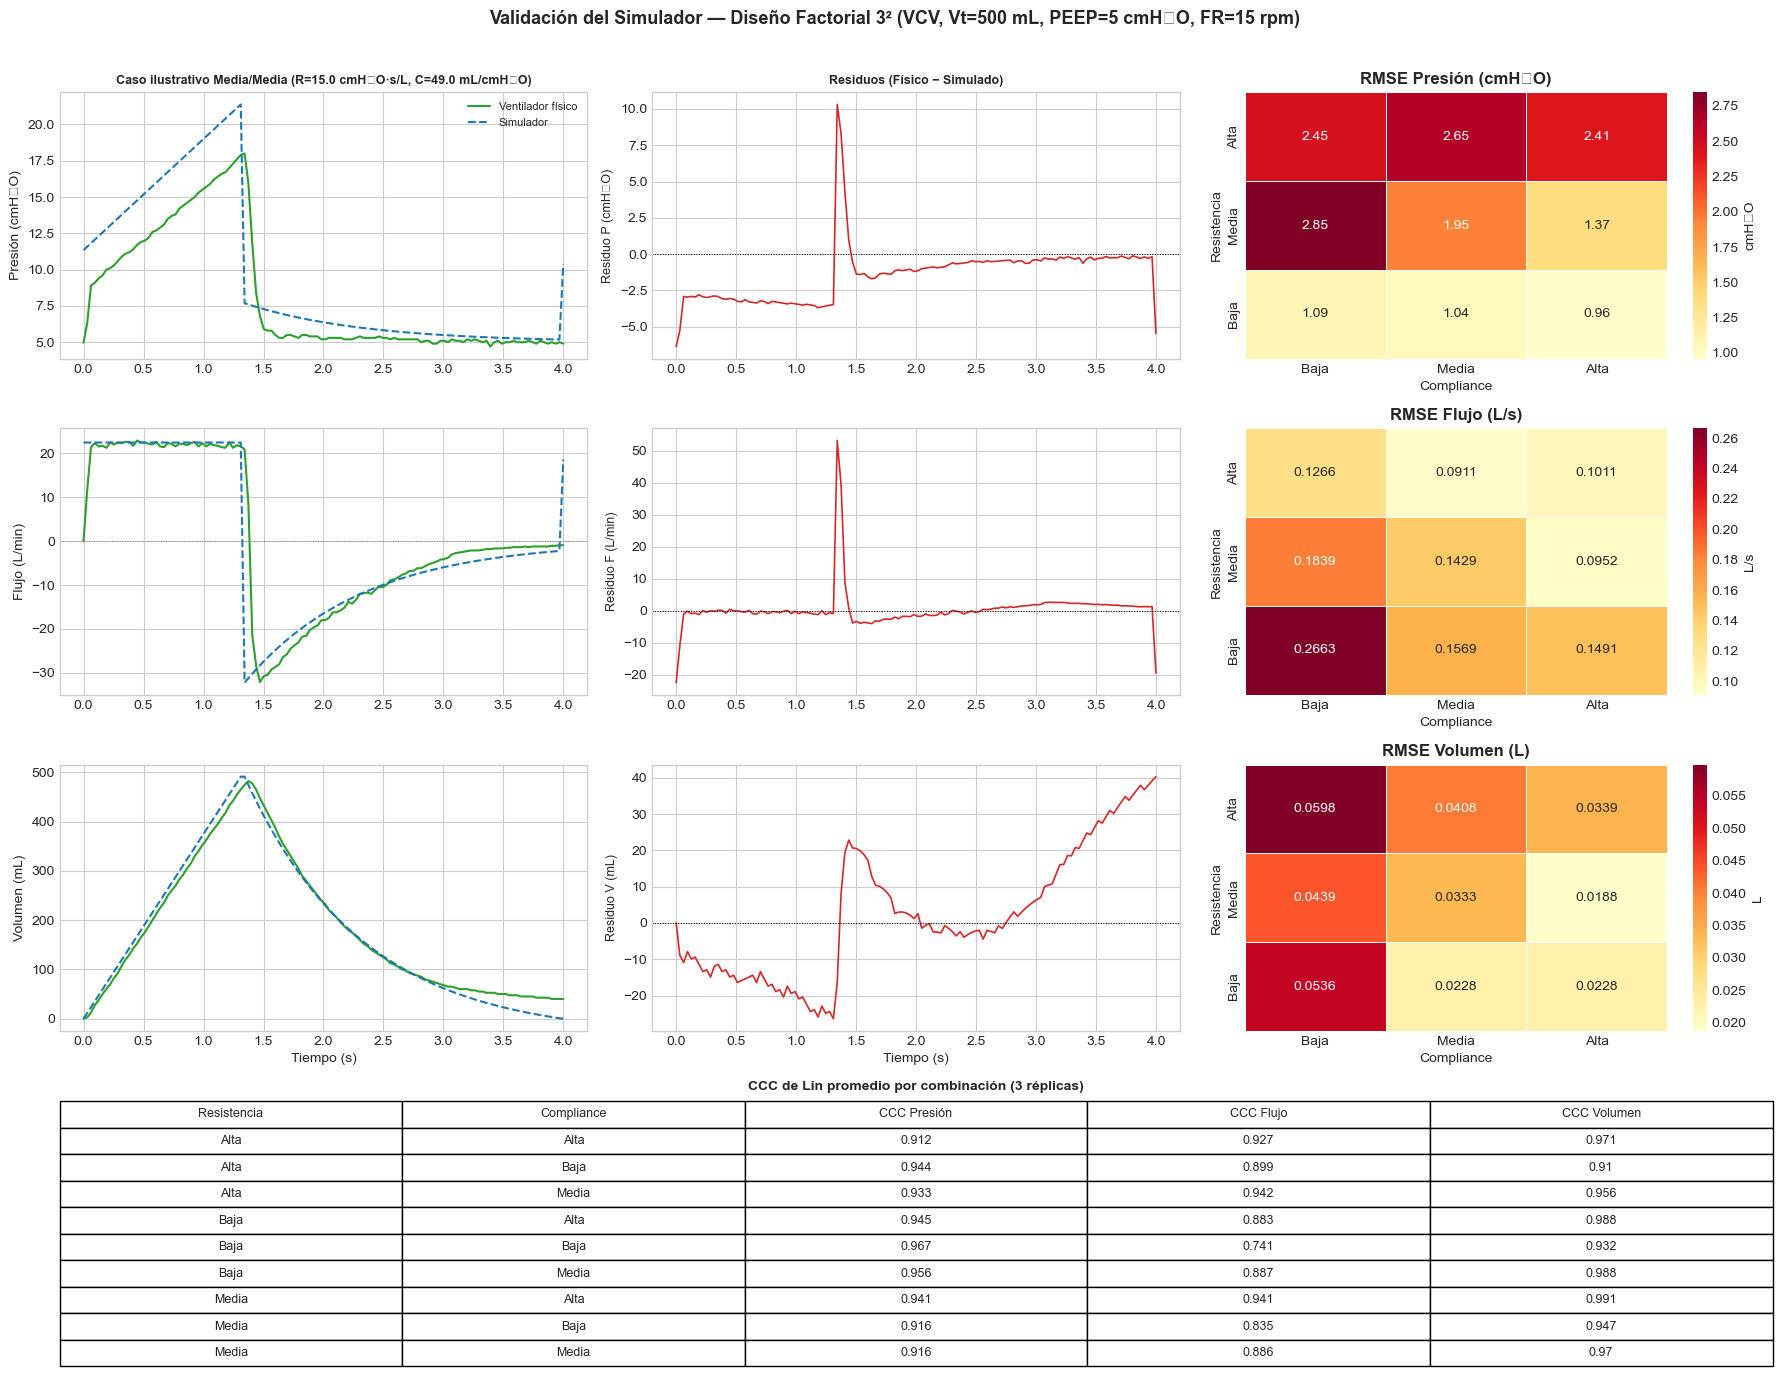

In [16]:
# ── Ordenamiento categórico para los ejes de los mapas de calor ────────────
ORD_R = ['Alta', 'Media', 'Baja']    # y-axis: R descendente
ORD_C = ['Baja', 'Media', 'Alta']    # x-axis: C ascendente

def heatmap_metrica(ax, df, col, titulo, cmap, fmt, label_cb):
    piv = (df.groupby(['Resistencia', 'Compliance'])[col]
             .mean()
             .reset_index()
             .pivot(index='Resistencia', columns='Compliance', values=col)
             .reindex(index=ORD_R, columns=ORD_C))
    sns.heatmap(piv, annot=True, cmap=cmap, fmt=fmt, ax=ax,
                cbar_kws={'label': label_cb}, linewidths=0.5)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Compliance')
    ax.set_ylabel('Resistencia')

# ── Dashboard 1: Series de tiempo (escenario Media/Media) + mapas RMSE ─────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Validación del Simulador — Diseño Factorial 3² (VCV, Vt=500 mL, PEEP=5 cmH₂O, FR=15 rpm)',
             fontsize=13, fontweight='bold', y=0.98)

# Colores
COL_FIS = '#2ca02c'   # verde: ventilador físico
COL_SIM = '#1f77b4'   # azul: simulador

d = datos_ejemplo
R_ej = d['R']
C_ej = d['C']
#titulo_ej = f'Escenario Media/Media  (R={R_ej} cmH₂O·s/L, C={C_ej} mL/cmH₂O)'
titulo_ej = (
    f'Caso ilustrativo Media/Media '
    f'(R={R_ej} cmH₂O·s/L, C={C_ej} mL/cmH₂O)'
)

# — Columna izquierda: series de tiempo P / F / V ——————————————————————————
ax_P = fig.add_subplot(4, 3, 1)
ax_F = fig.add_subplot(4, 3, 4, sharex=ax_P)
ax_V = fig.add_subplot(4, 3, 7, sharex=ax_P)

ax_P.plot(d['t'], d['P_fis'], color=COL_FIS, lw=1.5, label='Ventilador físico')
ax_P.plot(d['t'], d['P_sim'], color=COL_SIM, lw=1.5, ls='--', label='Simulador')
ax_P.set_ylabel('Presión (cmH₂O)')
ax_P.legend(fontsize=8)
ax_P.set_title(titulo_ej, fontweight='bold', fontsize=9)

ax_F.plot(d['t'], d['F_fis'] * 60, color=COL_FIS, lw=1.5)   # L/s → L/min para legibilidad
ax_F.plot(d['t'], d['F_sim'] * 60, color=COL_SIM, lw=1.5, ls='--')
ax_F.axhline(0, color='grey', lw=0.7, ls=':')
ax_F.set_ylabel('Flujo (L/min)')

ax_V.plot(d['t'], d['V_fis'] * 1000, color=COL_FIS, lw=1.5)  # L → mL
ax_V.plot(d['t'], d['V_sim'] * 1000, color=COL_SIM, lw=1.5, ls='--')
ax_V.set_ylabel('Volumen (mL)')
ax_V.set_xlabel('Tiempo (s)')

# — Columna central: residuos P / F / V ————————————————————————————————————
ax_rP = fig.add_subplot(4, 3, 2, sharex=ax_P)
ax_rF = fig.add_subplot(4, 3, 5, sharex=ax_P)
ax_rV = fig.add_subplot(4, 3, 8, sharex=ax_P)
COL_RES = '#d62728'

for ax_r, y_fis, y_sim, ylabel in [
    (ax_rP, d['P_fis'],        d['P_sim'],        'Residuo P (cmH₂O)'),
    (ax_rF, d['F_fis'] * 60,  d['F_sim'] * 60,  'Residuo F (L/min)'),
    (ax_rV, d['V_fis'] * 1000, d['V_sim'] * 1000, 'Residuo V (mL)'),
]:
    ax_r.plot(d['t'], y_fis - y_sim, color=COL_RES, lw=1.2)
    ax_r.axhline(0, color='black', lw=0.7, ls=':')
    ax_r.set_ylabel(ylabel, fontsize=9)

ax_rP.set_title('Residuos (Físico − Simulado)', fontweight='bold', fontsize=9)
ax_rV.set_xlabel('Tiempo (s)')

# — Columna derecha: mapas de calor RMSE ———————————————————————————————————
ax_hP = fig.add_subplot(4, 3, 3)
ax_hF = fig.add_subplot(4, 3, 6)
ax_hV = fig.add_subplot(4, 3, 9)

heatmap_metrica(ax_hP, df_res, 'RMSE_P', 'RMSE Presión (cmH₂O)',  'YlOrRd', '.2f', 'cmH₂O')
heatmap_metrica(ax_hF, df_res, 'RMSE_F', 'RMSE Flujo (L/s)',       'YlOrRd', '.4f', 'L/s')
heatmap_metrica(ax_hV, df_res, 'RMSE_V', 'RMSE Volumen (L)',        'YlOrRd', '.4f', 'L')

# — Fila inferior: tabla CCC promedio por combinación ——————————————————————
ax_tab = fig.add_subplot(4, 1, 4)
ax_tab.axis('off')

ccc_tabla = (df_res.groupby(['Resistencia', 'Compliance'])[['CCC_P', 'CCC_F', 'CCC_V']]
                   .mean()
                   .round(3)
                   .reset_index())
ccc_tabla.columns = ['Resistencia', 'Compliance', 'CCC Presión', 'CCC Flujo', 'CCC Volumen']

table = ax_tab.table(
    cellText=ccc_tabla.values,
    colLabels=ccc_tabla.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
ax_tab.set_title('CCC de Lin promedio por combinación (3 réplicas)',
                 fontweight='bold', fontsize=10, pad=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


      Parámetro  Estimación  IC95_inferior  IC95_superior
          Sesgo      -1.796         -2.238         -1.375
Límite inferior      -5.166         -6.246         -3.854
Límite superior       1.574          0.829          2.118


/var/folders/fj/m5l0ynr5059cvdqxm37ypbmc0000gn/T/ipykernel_33329/1983327480.py:124: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/julianquintana/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


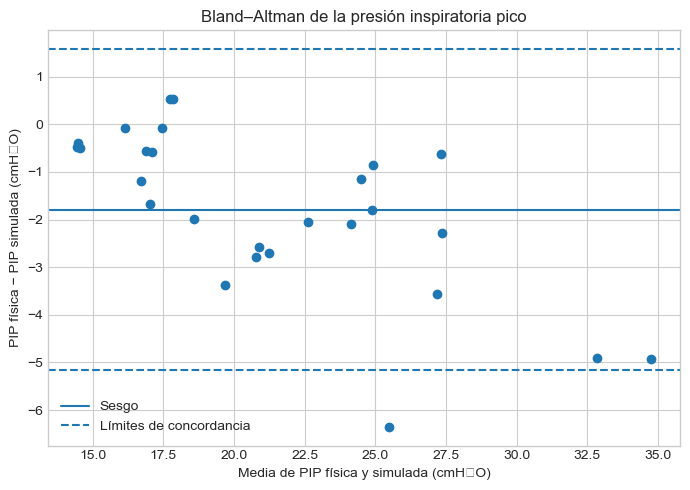

In [17]:
def bland_altman(
    df,
    n_bootstrap=10_000,
    semilla=42,
):
    """
    Bland–Altman para PIP.

    Diferencia = PIP física - PIP simulada.
    Un sesgo negativo indica que el simulador sobreestima la PIP.

    El bootstrap conserva las nueve combinaciones experimentales
    y remuestrea sus tres réplicas dentro de cada condición.
    """
    df = df.copy()

    df["media_PIP"] = (
        df["PIP_fis"] + df["PIP_sim"]
    ) / 2.0

    df["diferencia_PIP"] = (
        df["PIP_fis"] - df["PIP_sim"]
    )

    diferencias = df["diferencia_PIP"].to_numpy()

    sesgo = float(np.mean(diferencias))
    desviacion = float(np.std(diferencias, ddof=1))

    limite_inferior = sesgo - 1.96 * desviacion
    limite_superior = sesgo + 1.96 * desviacion

    rng = np.random.default_rng(semilla)

    grupos = [
        grupo["diferencia_PIP"].to_numpy()
        for _, grupo in df.groupby(
            ["Compliance", "Resistencia"]
        )
    ]

    bootstrap = np.empty(
        (n_bootstrap, 3),
        dtype=float,
    )

    for i in range(n_bootstrap):
        muestra = np.concatenate([
            rng.choice(
                grupo,
                size=len(grupo),
                replace=True,
            )
            for grupo in grupos
        ])

        sesgo_b = np.mean(muestra)
        desviacion_b = np.std(muestra, ddof=1)

        bootstrap[i] = [
            sesgo_b,
            sesgo_b - 1.96 * desviacion_b,
            sesgo_b + 1.96 * desviacion_b,
        ]

    intervalos = np.quantile(
        bootstrap,
        [0.025, 0.975],
        axis=0,
    )

    resumen = pd.DataFrame({
        "Parámetro": [
            "Sesgo",
            "Límite inferior",
            "Límite superior",
        ],
        "Estimación": [
            sesgo,
            limite_inferior,
            limite_superior,
        ],
        "IC95_inferior": intervalos[0],
        "IC95_superior": intervalos[1],
    })

    return df, resumen


df_ba_pip, resumen_ba_pip = (
    bland_altman(df_res)
)

print(resumen_ba_pip.round(3).to_string(index=False))

plt.figure(figsize=(7, 5))

plt.scatter(
    df_ba_pip["media_PIP"],
    df_ba_pip["diferencia_PIP"],
)

plt.axhline(
    resumen_ba_pip.loc[0, "Estimación"],
    linestyle="-",
    label="Sesgo",
)

plt.axhline(
    resumen_ba_pip.loc[1, "Estimación"],
    linestyle="--",
    label="Límites de concordancia",
)

plt.axhline(
    resumen_ba_pip.loc[2, "Estimación"],
    linestyle="--",
)

plt.xlabel("Media de PIP física y simulada (cmH₂O)")
plt.ylabel("PIP física − PIP simulada (cmH₂O)")
plt.title("Bland–Altman de la presión inspiratoria pico")
plt.legend()
plt.tight_layout()
plt.show()